In [1]:
from executor import Executor, QuantumCircuit, QuantumOperator, Parameters
from qulacsvis import circuit_drawer

In [2]:
x = Parameters("x", 1)
p = Parameters("p", 2)

qc = QuantumCircuit(2)
qc.h(0)
qc.cry(0, 1, p[0] * x[0])

In [3]:
pop = Parameters("pop", 2)
operator = QuantumOperator(["ZI", "IZ"], [pop[0], pop[1]])

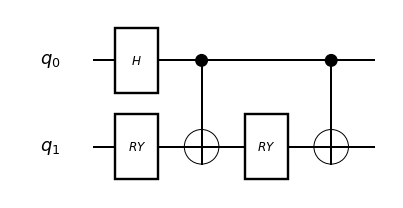

In [4]:
executor = Executor.create("qulacs", seed=0, shots=10000)

qulacs_circuit = executor.transpile_circuit(qc)
circuit_drawer(qulacs_circuit.get_circuit_func()([1.0], [2.0]), "mpl")

In [5]:
result = executor.expectation_value(
    qulacs_circuit,
    operator,
    x=[0.1],
    p=[0.3],
    pop=[0.5, 0.6],
)
print("Expectation value:", result)

Expectation value: 0.49988750843724694


In [6]:
v = executor.expectation_value_derivatives(
    qulacs_circuit,
    operator,
    "x",
    "p",
    "pop",
    x=[0.1],
    p=[0.3],
    pop=[0.5, 0.6],
)
print(v)

{'p': array([-0.00074989]), 'pop': array([9.99775017e-01, 1.04313802e-16]), 'x': array([-0.00224966])}


In [7]:
executor.statevector(
    qulacs_circuit,
    x=[0.8],
    p=[0.5],
)

array([7.07106781e-01+0.j, 6.93011723e-01+0.j, 1.38777878e-17+0.j,
       1.40480431e-01+0.j])

In [8]:
executor.sample(
    qulacs_circuit,
    x=[0.8],
    p=[0.5],
)

{np.str_('01'): 4815, np.str_('00'): 4990, np.str_('11'): 195}